# Trabalho Final — Segmentação Semântica de Imagens

**Disciplina:** Visão Computacional — UFMS
**Integrantes:** Jerfferson Jorge e Rafael Tsutomu
**Tarefa:** Segmentação semântica (Oxford-IIIT Pet)

---

Este notebook implementa e compara **três arquiteturas de segmentação semântica do zero** em
PyTorch — **FCN-8s**, **U-Net** e **DeepLabV3+** — sobre o dataset **Oxford-IIIT Pet** (trimap de
3 classes: animal, fundo e borda). Além do comparativo entre arquiteturas, realizamos experimentos
controlados (função de perda, *data augmentation*, *Batch Normalization* e *transfer learning*).

> **Como executar:** recomendado **Google Colab / Kaggle com GPU**. Rode as células em ordem
> (`Runtime → Run all`). O dataset é baixado automaticamente pelo `torchvision` na primeira execução.
> Veja o `README.md` para instruções detalhadas.

**O que é feito do zero:** as três arquiteturas (blocos e `forward`), as funções de perda
(Dice e CE+Dice), as métricas (IoU/mIoU, Dice, *pixel accuracy*) e o laço de treino.
**O que usamos pronto:** primitivas `nn.*`, download do dataset, otimizadores e pesos pré-treinados
(somente no experimento de *transfer learning*).

## 0. Setup

Imports, seleção de dispositivo, semente global para reprodutibilidade (`SEED = 42`, mesma
convenção do Trabalho 2) e hiperparâmetros globais usados em todo o notebook.

In [1]:
"""Setup global: imports, dispositivo, semente e hiperparâmetros."""
import os
import random
import time
from typing import Callable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt

SEED = 42


def set_seed(seed: int = SEED) -> None:
    """Fixa a semente em random, numpy e torch para reprodutibilidade."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hiperparâmetros globais
IMG_SIZE = 128          # resolução de treino (use 256 para o resultado final)
NUM_CLASSES = 3         # 0 = animal, 1 = fundo, 2 = borda
BATCH_SIZE = 16
EPOCHS = 30             # reduza para um teste rápido; aumente no Colab
LR = 1e-3
DATA_ROOT = "./data"

# Normalização ImageNet (necessária p/ o encoder pré-treinado e boa prática geral)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

CLASS_NAMES = ["animal", "fundo", "borda"]

print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__}")
print(f"Dispositivo: {device}")
print(f"CUDA disponível: {torch.cuda.is_available()}").

PyTorch 2.11.0+cu128 | torchvision 0.26.0+cu128
Dispositivo: cuda
CUDA disponível: True


## 1. Base de imagens — Oxford-IIIT Pet

O **Oxford-IIIT Pet** (Parkhi et al., 2012) traz ~7.349 imagens de cães e gatos, cada uma com uma
**máscara *trimap*** anotada pixel a pixel. Os valores originais do trimap são `1` (animal),
`2` (fundo) e `3` (borda/contorno); nós os **remapeamos para `0/1/2`** para servirem de rótulo ao
`CrossEntropyLoss`.

- **Divisão:** usamos o split oficial `trainval` (~3.680 imagens) e `test` (~3.669). Do `trainval`
  separamos **treino/validação 80/20 com `seed=42`**. O conjunto de **teste** só é usado na
  avaliação final.
- **Transforms conjuntas:** como imagem e máscara precisam sofrer as *mesmas* transformações
  geométricas, escrevemos uma transformação conjunta na mão (`JointTransform`), usando
  `torchvision.transforms.functional`. A máscara é redimensionada com interpolação
  **nearest** (para não criar rótulos inválidos); o *augmentation* fotométrico (`ColorJitter`)
  é aplicado **só na imagem**.

In [2]:
"""Transformação conjunta (imagem + máscara) feita na mão.

Garante que toda operação geométrica (resize, flip, affine) seja aplicada de forma idêntica
à imagem e à máscara. Operações fotométricas (ColorJitter) afetam apenas a imagem.
"""


def remap_trimap(mask: Tensor) -> Tensor:
    """Converte o trimap original (1=animal, 2=fundo, 3=borda) para rótulos 0/1/2."""
    return (mask.long() - 1).clamp(0, NUM_CLASSES - 1)


class JointTransform:
    """Aplica resize + (opcional) augmentation de forma sincronizada em imagem e máscara."""

    def __init__(self, size: int, train: bool = False, augment: bool = False) -> None:
        self.size = size
        self.train = train
        self.augment = augment
        self.color_jitter = torchvision.transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.2
        )

    def __call__(self, image, mask) -> tuple[Tensor, Tensor]:
        # Resize: imagem bilinear, máscara nearest
        image = TF.resize(image, [self.size, self.size],
                          interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size],
                         interpolation=TF.InterpolationMode.NEAREST)

        if self.train and self.augment:
            # Flip horizontal sincronizado
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            # Affine (rotação + translação) sincronizado; fundo da máscara preenchido com 2
            if random.random() < 0.5:
                angle = random.uniform(-15, 15)
                tx = random.uniform(-0.1, 0.1) * self.size
                ty = random.uniform(-0.1, 0.1) * self.size
                image = TF.affine(image, angle=angle, translate=[tx, ty], scale=1.0,
                                  shear=[0.0], interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.affine(mask, angle=angle, translate=[tx, ty], scale=1.0,
                                 shear=[0.0], interpolation=TF.InterpolationMode.NEAREST, fill=2)
            # ColorJitter só na imagem
            image = self.color_jitter(image)

        # Para tensor + normalização
        image = TF.to_tensor(image)
        image = TF.normalize(image, IMAGENET_MEAN, IMAGENET_STD)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)
        mask = remap_trimap(mask)
        return image, mask

In [3]:
"""Dataset wrapper que aplica a JointTransform sobre o OxfordIIITPet."""


class PetSegmentation(torch.utils.data.Dataset):
    """Envolve o OxfordIIITPet (target de segmentação) aplicando uma transformação conjunta."""

    def __init__(self, split: str, transform: JointTransform) -> None:
        self.base = OxfordIIITPet(
            root=DATA_ROOT, split=split, target_types="segmentation",
            download=True,
        )
        self.transform = transform

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        image, mask = self.base[idx]            # PIL.Image, PIL.Image
        image = image.convert("RGB")
        return self.transform(image, mask)


def build_dataloaders(img_size: int = IMG_SIZE, batch_size: int = BATCH_SIZE,
                      augment: bool = False) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Constrói os dataloaders de treino/validação/teste com split 80/20 (seed=42)."""
    train_tf = JointTransform(img_size, train=True, augment=augment)
    eval_tf = JointTransform(img_size, train=False, augment=False)

    # trainval -> split 80/20 reprodutível. Usamos dois datasets (transforms diferentes)
    # indexados pelos mesmos índices de split.
    full_train = PetSegmentation("trainval", train_tf)
    full_val = PetSegmentation("trainval", eval_tf)
    n = len(full_train)
    g = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(n, generator=g).tolist()
    n_val = int(0.2 * n)
    val_idx, train_idx = perm[:n_val], perm[n_val:]

    train_ds = Subset(full_train, train_idx)
    val_ds = Subset(full_val, val_idx)
    test_ds = PetSegmentation("test", eval_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2,
                              pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2,
                            pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2,
                             pin_memory=True)

    print(f"Treino: {len(train_ds)} | Validação: {len(val_ds)} | Teste: {len(test_ds)}")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(augment=False)

100%|██████████| 792M/792M [00:56<00:00, 14.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.3MB/s]


Treino: 2944 | Validação: 736 | Teste: 3669


### Visualizando amostras

Imagem, máscara *ground-truth* (3 classes) e a máscara sobreposta. Salvamos a figura em
`imagens/` para uso no relatório.

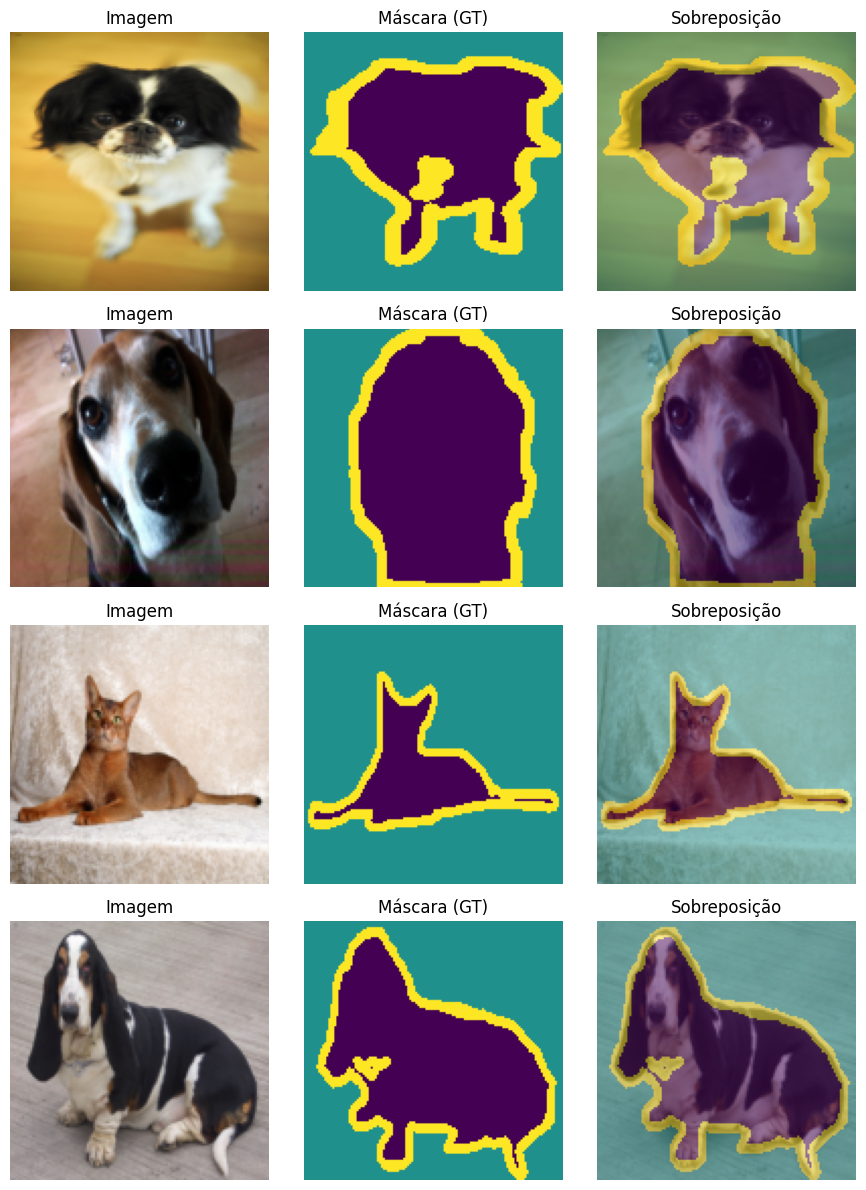

In [4]:
"""Desnormaliza um tensor de imagem e mostra amostras com suas máscaras."""


def denormalize(img: Tensor) -> np.ndarray:
    """Reverte a normalização ImageNet e retorna um array HxWx3 em [0,1]."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (img.cpu() * std + mean).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def show_samples(loader: DataLoader, n: int = 4, save: Optional[str] = None) -> None:
    """Mostra n amostras: imagem | máscara | sobreposição."""
    images, masks = next(iter(loader))
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    for i in range(n):
        img = denormalize(images[i])
        m = masks[i].numpy()
        axes[i, 0].imshow(img);                    axes[i, 0].set_title("Imagem")
        axes[i, 1].imshow(m, cmap="viridis", vmin=0, vmax=2); axes[i, 1].set_title("Máscara (GT)")
        axes[i, 2].imshow(img);                    axes[i, 2].imshow(m, cmap="viridis", alpha=0.5, vmin=0, vmax=2)
        axes[i, 2].set_title("Sobreposição")
        for j in range(3):
            axes[i, j].axis("off")
    plt.tight_layout()
    if save:
        os.makedirs(os.path.dirname(save), exist_ok=True)
        plt.savefig(save, dpi=120, bbox_inches="tight")
    plt.show()


show_samples(train_loader, n=4, save="imagens/amostras.png")

## 2. Métricas (do zero)

Para segmentação, as métricas adequadas são baseadas em **sobreposição** entre predição e
*ground-truth*. Implementamos do zero, acumulando uma **matriz de confusão** $C \times C$ sobre
todo o conjunto:

- **IoU por classe** (Intersection over Union): $\text{IoU}_c = \dfrac{TP_c}{TP_c + FP_c + FN_c}$
- **mIoU**: média das IoU por classe (métrica principal).
- **Dice coefficient**: $\text{Dice}_c = \dfrac{2\,TP_c}{2\,TP_c + FP_c + FN_c}$
- **Pixel accuracy**: fração de pixels classificados corretamente.

In [5]:
"""Acumulador de métricas de segmentação baseado em matriz de confusão (do zero)."""


class SegmentationMetrics:
    """Acumula uma matriz de confusão CxC e deriva IoU/mIoU, Dice e pixel accuracy."""

    def __init__(self, num_classes: int = NUM_CLASSES) -> None:
        self.num_classes = num_classes
        self.reset()

    def reset(self) -> None:
        self.confusion = torch.zeros(self.num_classes, self.num_classes, dtype=torch.long)

    @torch.no_grad()
    def update(self, preds: Tensor, targets: Tensor) -> None:
        """Atualiza a matriz de confusão. preds e targets: [B,H,W] (rótulos inteiros)."""
        preds = preds.flatten().cpu()
        targets = targets.flatten().cpu()
        k = (targets >= 0) & (targets < self.num_classes)
        idx = self.num_classes * targets[k] + preds[k]
        binc = torch.bincount(idx, minlength=self.num_classes ** 2)
        self.confusion += binc.reshape(self.num_classes, self.num_classes)

    def _tp_fp_fn(self):
        tp = torch.diag(self.confusion).float()
        fp = self.confusion.sum(0).float() - tp   # coluna = predição
        fn = self.confusion.sum(1).float() - tp   # linha = alvo
        return tp, fp, fn

    def iou_per_class(self) -> Tensor:
        tp, fp, fn = self._tp_fp_fn()
        return tp / (tp + fp + fn + 1e-7)

    def dice_per_class(self) -> Tensor:
        tp, fp, fn = self._tp_fp_fn()
        return 2 * tp / (2 * tp + fp + fn + 1e-7)

    def miou(self) -> float:
        return self.iou_per_class().mean().item()

    def dice(self) -> float:
        return self.dice_per_class().mean().item()

    def pixel_accuracy(self) -> float:
        return (torch.diag(self.confusion).sum() / (self.confusion.sum() + 1e-7)).item()

    def summary(self) -> dict:
        return {
            "miou": self.miou(),
            "dice": self.dice(),
            "pixel_acc": self.pixel_accuracy(),
            "iou_per_class": self.iou_per_class().tolist(),
        }

In [6]:
"""Teste trivial: predição == ground-truth deve dar IoU = Dice = 1."""
_m = SegmentationMetrics()
_gt = torch.randint(0, NUM_CLASSES, (2, 16, 16))
_m.update(_gt.clone(), _gt)
assert abs(_m.miou() - 1.0) < 1e-5 and abs(_m.dice() - 1.0) < 1e-5
print("Teste trivial das métricas OK (mIoU=1, Dice=1 quando predição = GT).")

Teste trivial das métricas OK (mIoU=1, Dice=1 quando predição = GT).


## 3. Funções de perda

- **Cross-Entropy** (`nn.CrossEntropyLoss`): baseline padrão para classificação por pixel.
- **Dice loss** (do zero): otimiza diretamente a sobreposição; ajuda quando há classes raras
  (a *borda*). Derivada do coeficiente de Dice: $\mathcal{L}_{Dice} = 1 - \text{Dice}$.
- **Combo (CE + Dice)** (do zero): soma das duas — estabilidade da CE + foco em sobreposição do Dice.

In [7]:
"""Dice loss multiclasse e perda combinada CE+Dice (implementadas do zero)."""


class DiceLoss(nn.Module):
    """Dice loss multiclasse a partir das probabilidades (softmax) e do alvo one-hot."""

    def __init__(self, num_classes: int = NUM_CLASSES, smooth: float = 1.0) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
        probs = F.softmax(logits, dim=1)                       # [B,C,H,W]
        target_1h = F.one_hot(targets, self.num_classes)       # [B,H,W,C]
        target_1h = target_1h.permute(0, 3, 1, 2).float()      # [B,C,H,W]
        dims = (0, 2, 3)
        inter = (probs * target_1h).sum(dims)
        cardinality = probs.sum(dims) + target_1h.sum(dims)
        dice = (2 * inter + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice.mean()


class ComboLoss(nn.Module):
    """Soma de Cross-Entropy e Dice loss."""

    def __init__(self, num_classes: int = NUM_CLASSES, weight_ce: float = 1.0,
                 weight_dice: float = 1.0) -> None:
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice

    def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
        return self.weight_ce * self.ce(logits, targets) + self.weight_dice * self.dice(logits, targets)

## 4. Motor de treino

Funções enxutas reutilizadas por **todas** as arquiteturas (mesmo padrão dos notebooks do
professor): `train_one_epoch`, `evaluate` (sob `@torch.no_grad`) e `fit`, que executa o laço
completo, registra o `history`, aplica o *scheduler* e guarda o **melhor modelo** pelo mIoU de
validação (*checkpoint*).

In [8]:
"""Laço de treino genérico: train_one_epoch, evaluate e fit (com checkpoint do melhor mIoU)."""


def train_one_epoch(model: nn.Module, loader: DataLoader, criterion: nn.Module,
                    optimizer: torch.optim.Optimizer) -> float:
    """Executa uma época de treino e retorna a perda média."""
    model.train()
    running = 0.0
    total = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running += loss.item() * images.size(0)
        total += images.size(0)
    return running / total


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> tuple[float, dict]:
    """Avalia o modelo: retorna a perda média e o dicionário de métricas."""
    model.eval()
    metrics = SegmentationMetrics()
    running = 0.0
    total = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        running += loss.item() * images.size(0)
        total += images.size(0)
        preds = logits.argmax(dim=1)
        metrics.update(preds, masks)
    return running / total, metrics.summary()


def fit(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
        criterion: nn.Module, epochs: int = EPOCHS, lr: float = LR,
        pretrained_params: Optional[list] = None) -> dict:
    """Treina o modelo por `epochs` épocas. Retorna history com curvas e o melhor state_dict."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "val_miou": [], "val_dice": [], "val_pixacc": []}
    best_miou = -1.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_m = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_miou"].append(val_m["miou"])
        history["val_dice"].append(val_m["dice"])
        history["val_pixacc"].append(val_m["pixel_acc"])

        if val_m["miou"] > best_miou:
            best_miou = val_m["miou"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Época {epoch:02d}/{epochs} | train_loss {train_loss:.4f} | "
              f"val_loss {val_loss:.4f} | mIoU {val_m['miou']:.4f} | "
              f"Dice {val_m['dice']:.4f} | pixAcc {val_m['pixel_acc']:.4f}")

    history["best_miou"] = best_miou
    history["best_state"] = best_state
    history["train_time"] = time.time() - t0
    print(f"\nMelhor mIoU (validação): {best_miou:.4f} | tempo: {history['train_time']:.0f}s")
    return history

## 5. Arquitetura B — U-Net (do zero)

> Implementamos a **U-Net primeiro** por ser nossa arquitetura central e o caminho mais direto para
> validar o *pipeline* de ponta a ponta. As arquiteturas FCN-8s e DeepLabV3+ vêm nas seções 6 e 7.

A U-Net (Ronneberger et al., 2015) é um *encoder-decoder* simétrico com **skip connections** por
concatenação: o decoder recupera a resolução espacial reaproveitando os mapas de ativação de alta
resolução do encoder.

- **`DoubleConv`**: `Conv3×3 → (BN) → ReLU` aplicado duas vezes.
- **Encoder**: 4 estágios de `MaxPool → DoubleConv` (64→128→256→512→1024).
- **Decoder**: 4 estágios de `up (ConvTranspose) → concat com skip → DoubleConv`.
- **`OutConv`**: `Conv1×1` projetando para `num_classes`.

O `BatchNorm` (ativável por `use_bn`) é uma adição moderna ao paper original — vira um experimento.

In [9]:
"""U-Net implementada do zero (DoubleConv, Down, Up, OutConv, UNet)."""


class DoubleConv(nn.Module):
    """(Conv3x3 -> [BN] -> ReLU) x2."""

    def __init__(self, in_ch: int, out_ch: int, use_bn: bool = True) -> None:
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=not use_bn)]
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=not use_bn))
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.block(x)


class Down(nn.Module):
    """Downscaling: MaxPool2x2 seguido de DoubleConv."""

    def __init__(self, in_ch: int, out_ch: int, use_bn: bool = True) -> None:
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch, use_bn)

    def forward(self, x: Tensor) -> Tensor:
        return self.conv(self.pool(x))


class Up(nn.Module):
    """Upscaling: ConvTranspose2x2, concat com a skip connection e DoubleConv."""

    def __init__(self, in_ch: int, out_ch: int, use_bn: bool = True) -> None:
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch, use_bn)

    def forward(self, x: Tensor, skip: Tensor) -> Tensor:
        x = self.up(x)
        # Ajuste de tamanho caso haja diferença por arredondamento
        dy = skip.size(2) - x.size(2)
        dx = skip.size(3) - x.size(3)
        x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    """U-Net completa para segmentação semântica."""

    def __init__(self, num_classes: int = NUM_CLASSES, in_ch: int = 3, use_bn: bool = True) -> None:
        super().__init__()
        self.inc = DoubleConv(in_ch, 64, use_bn)
        self.down1 = Down(64, 128, use_bn)
        self.down2 = Down(128, 256, use_bn)
        self.down3 = Down(256, 512, use_bn)
        self.down4 = Down(512, 1024, use_bn)
        self.up1 = Up(1024, 512, use_bn)
        self.up2 = Up(512, 256, use_bn)
        self.up3 = Up(256, 128, use_bn)
        self.up4 = Up(128, 64, use_bn)
        self.outc = nn.Conv2d(64, num_classes, kernel_size=1)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

In [10]:
"""Verificação da U-Net: shapes de entrada/saída e contagem de parâmetros."""


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


def check_model(model: nn.Module, name: str) -> None:
    """Passa um tensor aleatório e confere que a saída tem o shape esperado."""
    model.eval()
    x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    with torch.no_grad():
        y = model(x)
    assert y.shape == (2, NUM_CLASSES, IMG_SIZE, IMG_SIZE), f"shape inesperado: {tuple(y.shape)}"
    print(f"{name:12s} | entrada {tuple(x.shape)} -> saída {tuple(y.shape)} | "
          f"{count_params(model)/1e6:.2f}M parâmetros")


check_model(UNet(), "U-Net")

U-Net        | entrada (2, 3, 128, 128) -> saída (2, 3, 128, 128) | 31.04M parâmetros


### Sanidade do pipeline: *overfit* de 1 batch

Teste clássico de corretude: o modelo deve conseguir **decorar um único batch** (perda → ~0).
Se isso falhar, há bug no modelo/perda/treino antes de gastar tempo num treino completo.

In [11]:
"""Overfit de 1 batch: a perda deve cair fortemente em poucas iterações."""
set_seed(SEED)
_model = UNet().to(device)
_images, _masks = next(iter(train_loader))
_images, _masks = _images.to(device), _masks.to(device)
_crit = nn.CrossEntropyLoss()
_opt = torch.optim.Adam(_model.parameters(), lr=1e-3)
_model.train()
for it in range(30):
    _opt.zero_grad()
    _loss = _crit(_model(_images), _masks)
    _loss.backward()
    _opt.step()
    if it % 10 == 0 or it == 29:
        print(f"iter {it:02d} | loss {_loss.item():.4f}")
print("Se a perda caiu bastante, o pipeline (modelo+perda+treino) está correto.")
del _model, _images, _masks

iter 00 | loss 4.1066
iter 10 | loss 0.7367
iter 20 | loss 0.4107
iter 29 | loss 0.3027
Se a perda caiu bastante, o pipeline (modelo+perda+treino) está correto.


## 6. Arquitetura A — FCN-8s (do zero)

A **FCN** (Long et al., 2015) foi a primeira rede totalmente convolucional para segmentação densa.
A variante **FCN-8s** produz predições mais finas ao **fundir** os mapas de baixa resolução
(`pool5`) com mapas intermediários (`pool4`, `pool3`) via *skip connections* aditivas, antes do
*upsampling* final. É nosso **baseline**: tende a produzir contornos mais grosseiros que a U-Net.

In [12]:
"""FCN-8s implementada do zero (encoder estilo VGG + fusão de skips pool3/pool4)."""


class FCN8s(nn.Module):
    """Fully Convolutional Network (variante 8s) para segmentação semântica."""

    def __init__(self, num_classes: int = NUM_CLASSES, in_ch: int = 3) -> None:
        super().__init__()

        def vgg_block(cin: int, cout: int, n: int) -> nn.Sequential:
            layers: list[nn.Module] = []
            for i in range(n):
                layers += [nn.Conv2d(cin if i == 0 else cout, cout, 3, padding=1),
                           nn.BatchNorm2d(cout), nn.ReLU(inplace=True)]
            layers.append(nn.MaxPool2d(2, ceil_mode=True))
            return nn.Sequential(*layers)

        self.block1 = vgg_block(in_ch, 64, 2)    # /2
        self.block2 = vgg_block(64, 128, 2)      # /4
        self.block3 = vgg_block(128, 256, 3)     # /8  -> pool3
        self.block4 = vgg_block(256, 512, 3)     # /16 -> pool4
        self.block5 = vgg_block(512, 512, 3)     # /32 -> pool5

        self.classifier = nn.Sequential(
            nn.Conv2d(512, 1024, 3, padding=1), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Conv2d(1024, 1024, 1), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Conv2d(1024, num_classes, 1),
        )
        self.score_pool4 = nn.Conv2d(512, num_classes, 1)
        self.score_pool3 = nn.Conv2d(256, num_classes, 1)
        self.up2a = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self.up2b = nn.ConvTranspose2d(num_classes, num_classes, 4, stride=2, padding=1)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    @staticmethod
    def _crop_add(x: Tensor, skip: Tensor) -> Tensor:
        """Alinha x ao tamanho de skip (corte) e soma."""
        x = x[..., : skip.size(2), : skip.size(3)]
        return x + skip

    def forward(self, x: Tensor) -> Tensor:
        h, w = x.shape[-2:]
        p1 = self.block1(x)
        p2 = self.block2(p1)
        p3 = self.block3(p2)
        p4 = self.block4(p3)
        p5 = self.block5(p4)

        s = self.classifier(p5)                 # /32
        s = self.up2a(s)                        # /16
        s = self._crop_add(s, self.score_pool4(p4))
        s = self.up2b(s)                        # /8
        s = self._crop_add(s, self.score_pool3(p3))
        # upsample final (8x) até a resolução de entrada
        s = F.interpolate(s, size=(h, w), mode="bilinear", align_corners=False)
        return s


check_model(FCN8s(), "FCN-8s")

FCN-8s       | entrada (2, 3, 128, 128) -> saída (2, 3, 128, 128) | 20.50M parâmetros


## 7. Arquitetura C — DeepLabV3+ (do zero)

O **DeepLabV3+** (Chen et al., 2018) combina três ideias:
1. **Atrous (dilated) convolutions** no *backbone*, que aumentam o campo receptivo sem reduzir a
   resolução (mantemos *output stride* 16).
2. **ASPP** (Atrous Spatial Pyramid Pooling): convoluções paralelas com diferentes taxas de
   dilatação + *pooling* global, capturando contexto em múltiplas escalas.
3. **Decoder** leve que funde *low-level features* (alta resolução) para refinar os contornos.

Implementamos um *backbone* ResNet do zero (reaproveitando um `BasicBlock` com suporte a dilatação),
o módulo ASPP e o decoder.

In [13]:
"""Backbone ResNet do zero (com dilatação) usado pelo DeepLabV3+."""


class BasicBlock(nn.Module):
    """Bloco residual 3x3 + 3x3 com suporte a dilatação (estilo ResNet-18/34)."""

    expansion = 1

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1,
                 dilation: int = 1, downsample: Optional[nn.Module] = None) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride,
                               padding=dilation, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=dilation, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.downsample = downsample

    def forward(self, x: Tensor) -> Tensor:
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResNetBackbone(nn.Module):
    """ResNet-18 (do zero) com output stride 16: layer4 usa dilatação em vez de stride."""

    def __init__(self, in_ch: int = 3) -> None:
        super().__init__()
        self.in_ch = 64
        self.stem = nn.Sequential(
            nn.Conv2d(in_ch, 64, 7, stride=2, padding=3, bias=False),  # /2
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),                      # /4
        )
        self.layer1 = self._make_layer(64, 2, stride=1)                # /4   (low-level)
        self.layer2 = self._make_layer(128, 2, stride=2)               # /8
        self.layer3 = self._make_layer(256, 2, stride=2)               # /16
        self.layer4 = self._make_layer(512, 2, stride=1, dilation=2)   # /16  (atrous)

    def _make_layer(self, out_ch: int, blocks: int, stride: int, dilation: int = 1) -> nn.Sequential:
        downsample = None
        if stride != 1 or self.in_ch != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        layers = [BasicBlock(self.in_ch, out_ch, stride, dilation, downsample)]
        self.in_ch = out_ch
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_ch, out_ch, dilation=dilation))
        return nn.Sequential(*layers)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        x = self.stem(x)
        low = self.layer1(x)        # stride 4
        x = self.layer2(low)
        x = self.layer3(x)
        high = self.layer4(x)       # stride 16
        return low, high

In [14]:
"""Módulo ASPP e o modelo DeepLabV3+ completo (do zero)."""


class ASPP(nn.Module):
    """Atrous Spatial Pyramid Pooling: contexto multi-escala via dilatações + pooling global."""

    def __init__(self, in_ch: int, out_ch: int = 256, rates: tuple = (6, 12, 18)) -> None:
        super().__init__()
        self.b0 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=r, dilation=r, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
            for r in rates
        ])
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True))
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (len(rates) + 2), out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True), nn.Dropout(0.5))

    def forward(self, x: Tensor) -> Tensor:
        size = x.shape[-2:]
        feats = [self.b0(x)] + [b(x) for b in self.branches]
        pooled = self.pool(x)
        pooled = F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)
        feats.append(pooled)
        return self.project(torch.cat(feats, dim=1))


class DeepLabV3Plus(nn.Module):
    """DeepLabV3+ do zero: backbone ResNet com atrous + ASPP + decoder com low-level features."""

    def __init__(self, num_classes: int = NUM_CLASSES, in_ch: int = 3) -> None:
        super().__init__()
        self.backbone = ResNetBackbone(in_ch)
        self.aspp = ASPP(512, 256)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(64, 48, 1, bias=False), nn.BatchNorm2d(48), nn.ReLU(inplace=True))
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )
        self.classifier = nn.Conv2d(256, num_classes, 1)
        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        size = x.shape[-2:]
        low, high = self.backbone(x)
        x = self.aspp(high)
        x = F.interpolate(x, size=low.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_level_proj(low)
        x = torch.cat([x, low], dim=1)
        x = self.decoder(x)
        x = self.classifier(x)
        return F.interpolate(x, size=size, mode="bilinear", align_corners=False)


check_model(DeepLabV3Plus(), "DeepLabV3+")

DeepLabV3+   | entrada (2, 3, 128, 128) -> saída (2, 3, 128, 128) | 16.60M parâmetros


## 8. Comparativo de arquiteturas

Treinamos as **três arquiteturas no mesmo setup** (mesma perda CE, mesmas épocas, mesmo
*augmentation* desligado, `seed=42`) e comparamos por **mIoU / Dice / pixel accuracy**, número de
parâmetros e tempo de treino. Esse é o comparativo central do trabalho.

> **Custo:** treinar as três é a parte mais pesada. No Colab com GPU é tranquilo; reduza `EPOCHS`
> para um teste rápido.

In [15]:
"""Treina as três arquiteturas no mesmo setup e coleta os resultados."""
architectures = {
    "FCN-8s": FCN8s,
    "U-Net": UNet,
    "DeepLabV3+": DeepLabV3Plus,
}

results = {}
histories = {}
criterion_ce = nn.CrossEntropyLoss()

for name, ctor in architectures.items():
    print(f"\n===== Treinando {name} =====")
    set_seed(SEED)
    model = ctor()
    hist = fit(model, train_loader, val_loader, criterion_ce, epochs=EPOCHS, lr=LR)
    histories[name] = hist
    results[name] = {
        "params_M": count_params(model) / 1e6,
        "best_miou": hist["best_miou"],
        "final_dice": hist["val_dice"][-1],
        "final_pixacc": hist["val_pixacc"][-1],
        "train_time_s": hist["train_time"],
        "best_state": hist["best_state"],
    }


===== Treinando FCN-8s =====
Época 01/30 | train_loss 1.6353 | val_loss 0.6795 | mIoU 0.4633 | Dice 0.6051 | pixAcc 0.7173
Época 02/30 | train_loss 0.6421 | val_loss 0.6147 | mIoU 0.4738 | Dice 0.6009 | pixAcc 0.7544
Época 03/30 | train_loss 0.5999 | val_loss 0.5838 | mIoU 0.4820 | Dice 0.6045 | pixAcc 0.7688
Época 04/30 | train_loss 0.5648 | val_loss 0.5502 | mIoU 0.5290 | Dice 0.6655 | pixAcc 0.7793
Época 05/30 | train_loss 0.5415 | val_loss 0.5485 | mIoU 0.5345 | Dice 0.6673 | pixAcc 0.7854
Época 06/30 | train_loss 0.5197 | val_loss 0.5780 | mIoU 0.5277 | Dice 0.6662 | pixAcc 0.7683
Época 07/30 | train_loss 0.4982 | val_loss 0.4841 | mIoU 0.5670 | Dice 0.6939 | pixAcc 0.8108
Época 08/30 | train_loss 0.4676 | val_loss 0.4979 | mIoU 0.5680 | Dice 0.6993 | pixAcc 0.8024
Época 09/30 | train_loss 0.4436 | val_loss 0.4703 | mIoU 0.5624 | Dice 0.6864 | pixAcc 0.8154
Época 10/30 | train_loss 0.4322 | val_loss 0.4569 | mIoU 0.5817 | Dice 0.7059 | pixAcc 0.8236
Época 11/30 | train_loss 0.418

In [16]:
"""Tabela-resumo do comparativo de arquiteturas."""
print(f"{'Arquitetura':<14}{'Params(M)':>10}{'mIoU':>9}{'Dice':>9}{'pixAcc':>9}{'Tempo(s)':>10}")
print("-" * 61)
for name, r in results.items():
    print(f"{name:<14}{r['params_M']:>10.2f}{r['best_miou']:>9.4f}"
          f"{r['final_dice']:>9.4f}{r['final_pixacc']:>9.4f}{r['train_time_s']:>10.0f}")

Arquitetura    Params(M)     mIoU     Dice   pixAcc  Tempo(s)
-------------------------------------------------------------
FCN-8s             20.50   0.6788   0.7891   0.8731       710
U-Net              31.04   0.7282   0.8295   0.8961      1460
DeepLabV3+         16.60   0.6720   0.7799   0.8640       583


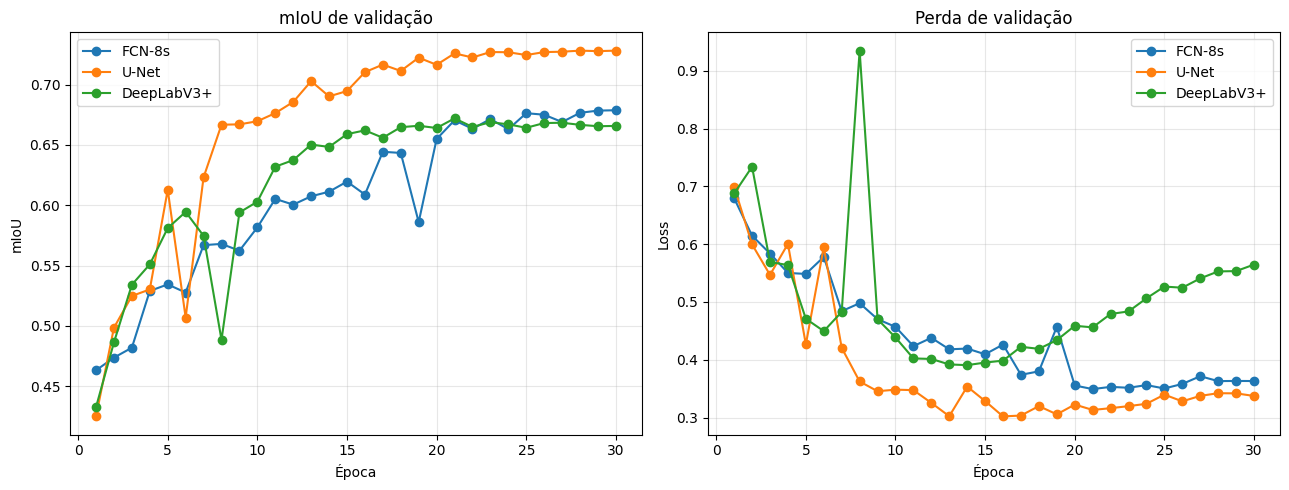

In [17]:
"""Curvas de mIoU e perda de validação para as três arquiteturas."""
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, hist in histories.items():
    epochs_range = range(1, len(hist["val_miou"]) + 1)
    axes[0].plot(epochs_range, hist["val_miou"], marker="o", label=name)
    axes[1].plot(epochs_range, hist["val_loss"], marker="o", label=name)
axes[0].set_title("mIoU de validação"); axes[0].set_xlabel("Época"); axes[0].set_ylabel("mIoU")
axes[1].set_title("Perda de validação"); axes[1].set_xlabel("Época"); axes[1].set_ylabel("Loss")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("imagens/comparativo_arquiteturas.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Experimentos controlados (ablações)

Tomamos a **melhor arquitetura** do comparativo e variamos um fator por vez (`seed=42`):

1. **Função de perda:** CE vs Dice vs CE+Dice.
2. **Data augmentation:** com vs sem.
3. **Batch Normalization:** com vs sem (apenas U-Net, via `use_bn`).
4. **Transfer learning:** encoder pré-treinado (ImageNet) vs do zero.

Para manter o custo razoável usamos `ABLATION_EPOCHS` (≤ `EPOCHS`).

In [18]:
"""Seleciona a melhor arquitetura do comparativo para as ablações."""
best_arch = max(results, key=lambda k: results[k]["best_miou"])
best_ctor = architectures[best_arch]
ABLATION_EPOCHS = max(10, EPOCHS // 2)
print(f"Melhor arquitetura: {best_arch} (mIoU={results[best_arch]['best_miou']:.4f})")
print(f"Épocas das ablações: {ABLATION_EPOCHS}")

ablation_results = {}


def run_ablation(tag: str, model: nn.Module, loaders, criterion, epochs=ABLATION_EPOCHS, lr=LR):
    """Roda um experimento de ablação e registra o melhor mIoU."""
    tl, vl = loaders
    print(f"\n----- Ablação: {tag} -----")
    set_seed(SEED)
    hist = fit(model, tl, vl, criterion, epochs=epochs, lr=lr)
    ablation_results[tag] = hist["best_miou"]
    return hist

Melhor arquitetura: U-Net (mIoU=0.7282)
Épocas das ablações: 15


In [19]:
"""Ablação 1 — Função de perda (CE vs Dice vs CE+Dice)."""
for tag, crit in [("Perda: CE", nn.CrossEntropyLoss()),
                  ("Perda: Dice", DiceLoss()),
                  ("Perda: CE+Dice", ComboLoss())]:
    run_ablation(tag, best_ctor(), (train_loader, val_loader), crit)


----- Ablação: Perda: CE -----
Época 01/15 | train_loss 0.8089 | val_loss 0.6394 | mIoU 0.4621 | Dice 0.5960 | pixAcc 0.7451
Época 02/15 | train_loss 0.6013 | val_loss 0.5950 | mIoU 0.5043 | Dice 0.6428 | pixAcc 0.7627
Época 03/15 | train_loss 0.5440 | val_loss 0.5209 | mIoU 0.5424 | Dice 0.6704 | pixAcc 0.8002
Época 04/15 | train_loss 0.4868 | val_loss 0.4546 | mIoU 0.6006 | Dice 0.7262 | pixAcc 0.8273
Época 05/15 | train_loss 0.4387 | val_loss 0.4375 | mIoU 0.6099 | Dice 0.7343 | pixAcc 0.8327
Época 06/15 | train_loss 0.3989 | val_loss 0.4056 | mIoU 0.6345 | Dice 0.7576 | pixAcc 0.8445
Época 07/15 | train_loss 0.3685 | val_loss 0.3893 | mIoU 0.6415 | Dice 0.7597 | pixAcc 0.8557
Época 08/15 | train_loss 0.3348 | val_loss 0.3424 | mIoU 0.6753 | Dice 0.7890 | pixAcc 0.8701
Época 09/15 | train_loss 0.3071 | val_loss 0.3410 | mIoU 0.6728 | Dice 0.7854 | pixAcc 0.8722
Época 10/15 | train_loss 0.2875 | val_loss 0.3305 | mIoU 0.6895 | Dice 0.7997 | pixAcc 0.8783
Época 11/15 | train_loss 0.2

In [20]:
"""Ablação 2 — Data augmentation (com vs sem)."""
train_aug, val_aug, _ = build_dataloaders(augment=True)
run_ablation("Augmentation: não", best_ctor(), (train_loader, val_loader), nn.CrossEntropyLoss())
run_ablation("Augmentation: sim", best_ctor(), (train_aug, val_aug), nn.CrossEntropyLoss())

Treino: 2944 | Validação: 736 | Teste: 3669

----- Ablação: Augmentation: não -----
Época 01/15 | train_loss 0.8657 | val_loss 0.7388 | mIoU 0.4370 | Dice 0.5711 | pixAcc 0.7146
Época 02/15 | train_loss 0.6107 | val_loss 0.6002 | mIoU 0.5031 | Dice 0.6396 | pixAcc 0.7567
Época 03/15 | train_loss 0.5462 | val_loss 0.5355 | mIoU 0.5362 | Dice 0.6659 | pixAcc 0.7953
Época 04/15 | train_loss 0.4851 | val_loss 0.4734 | mIoU 0.5817 | Dice 0.7091 | pixAcc 0.8199
Época 05/15 | train_loss 0.4333 | val_loss 0.4426 | mIoU 0.6093 | Dice 0.7342 | pixAcc 0.8311
Época 06/15 | train_loss 0.3944 | val_loss 0.4199 | mIoU 0.6180 | Dice 0.7442 | pixAcc 0.8349
Época 07/15 | train_loss 0.3674 | val_loss 0.3859 | mIoU 0.6461 | Dice 0.7650 | pixAcc 0.8559
Época 08/15 | train_loss 0.3345 | val_loss 0.3547 | mIoU 0.6654 | Dice 0.7800 | pixAcc 0.8660
Época 09/15 | train_loss 0.3127 | val_loss 0.3412 | mIoU 0.6709 | Dice 0.7846 | pixAcc 0.8691
Época 10/15 | train_loss 0.2917 | val_loss 0.3305 | mIoU 0.6882 | Dice

{'train_loss': [0.7840839834964793,
  0.5984670126243777,
  0.5371028149257535,
  0.48380850611821463,
  0.4327455793061982,
  0.4033773322792157,
  0.3772581281221431,
  0.3498519030602082,
  0.3348867206469826,
  0.31539866862737614,
  0.2967935995725186,
  0.28671828867948573,
  0.2748187541475762,
  0.2638535071974215,
  0.2616574521297994],
 'val_loss': [0.6874691986519358,
  0.5681598432686018,
  0.507390637760577,
  0.4580735952957817,
  0.41918332874774933,
  0.4076883559641631,
  0.3726035440745561,
  0.34378826456225436,
  0.338755731349406,
  0.3319884622874467,
  0.31422735847856686,
  0.3013328158337137,
  0.2888631720257842,
  0.28696884700785513,
  0.28415317153153213],
 'val_miou': [0.44065675139427185,
  0.5149772763252258,
  0.5576362609863281,
  0.5972301363945007,
  0.6168667674064636,
  0.6367654204368591,
  0.6466802954673767,
  0.6687769889831543,
  0.6657576560974121,
  0.6811830997467041,
  0.6928880214691162,
  0.7003403306007385,
  0.7082371115684509,
  0.709

In [21]:
"""Ablação 3 — Batch Normalization na U-Net (com vs sem)."""
run_ablation("BatchNorm: sim", UNet(use_bn=True), (train_loader, val_loader), nn.CrossEntropyLoss())
run_ablation("BatchNorm: não", UNet(use_bn=False), (train_loader, val_loader), nn.CrossEntropyLoss())


----- Ablação: BatchNorm: sim -----
Época 01/15 | train_loss 0.8507 | val_loss 0.7953 | mIoU 0.4431 | Dice 0.5728 | pixAcc 0.7262
Época 02/15 | train_loss 0.5957 | val_loss 0.6003 | mIoU 0.4954 | Dice 0.6238 | pixAcc 0.7618
Época 03/15 | train_loss 0.5334 | val_loss 0.5070 | mIoU 0.5569 | Dice 0.6868 | pixAcc 0.8020
Época 04/15 | train_loss 0.4742 | val_loss 0.4557 | mIoU 0.5860 | Dice 0.7109 | pixAcc 0.8231
Época 05/15 | train_loss 0.4200 | val_loss 0.4270 | mIoU 0.6083 | Dice 0.7310 | pixAcc 0.8364
Época 06/15 | train_loss 0.3817 | val_loss 0.4031 | mIoU 0.6281 | Dice 0.7510 | pixAcc 0.8435
Época 07/15 | train_loss 0.3515 | val_loss 0.4062 | mIoU 0.6324 | Dice 0.7535 | pixAcc 0.8497
Época 08/15 | train_loss 0.3217 | val_loss 0.3530 | mIoU 0.6683 | Dice 0.7830 | pixAcc 0.8668
Época 09/15 | train_loss 0.2994 | val_loss 0.3546 | mIoU 0.6629 | Dice 0.7778 | pixAcc 0.8663
Época 10/15 | train_loss 0.2766 | val_loss 0.3601 | mIoU 0.6775 | Dice 0.7902 | pixAcc 0.8719
Época 11/15 | train_los

{'train_loss': [0.9137108795668768,
  0.616532322505246,
  0.538242908599584,
  0.47599339809106744,
  0.42356894877941714,
  0.3865889856672805,
  0.3553800471936879,
  0.3326558933147918,
  0.29509512569917284,
  0.2644482856697362,
  0.2353766258482052,
  0.21111841750857624,
  0.1947249932943479,
  0.18361857452470323,
  0.17820880359605604],
 'val_loss': [0.6605296070161073,
  0.5775057608666627,
  0.48340367752572766,
  0.45981478237587475,
  0.4156513194675031,
  0.4016612729300623,
  0.4070622292549714,
  0.3536793311005053,
  0.38200770383295807,
  0.36625181008940155,
  0.3652613153276236,
  0.37038989267919376,
  0.39163175937922107,
  0.4001465213039647,
  0.41151055887989374],
 'val_miou': [0.4287298917770386,
  0.500698447227478,
  0.5727872252464294,
  0.6018005013465881,
  0.6234506964683533,
  0.6397973895072937,
  0.6188274025917053,
  0.6663643717765808,
  0.6667765974998474,
  0.6746492981910706,
  0.685677707195282,
  0.6865749955177307,
  0.6868695616722107,
  0.6

In [22]:
"""Ablação 4 — Transfer learning: U-Net com encoder ResNet-34 pré-treinado (ImageNet).

Aqui usamos pesos prontos do torchvision SOMENTE para o encoder; o decoder é treinado do zero.
"""
from torchvision.models import resnet34, ResNet34_Weights


class UpFlex(nn.Module):
    """Bloco de decoder flexível: upsample + concat com skip de canais arbitrários + DoubleConv."""

    def __init__(self, in_ch: int, skip_ch: int, out_ch: int) -> None:
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x: Tensor, skip: Tensor) -> Tensor:
        x = self.up(x)
        dy = skip.size(2) - x.size(2)
        dx = skip.size(3) - x.size(3)
        x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([skip, x], dim=1))


class UNetResNet34(nn.Module):
    """U-Net cujo encoder é uma ResNet-34 (opcionalmente pré-treinada no ImageNet)."""

    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True) -> None:
        super().__init__()
        weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = resnet34(weights=weights)
        self.input_block = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)  # /2, 64
        self.pool = backbone.maxpool
        self.enc1 = backbone.layer1   # /4,  64
        self.enc2 = backbone.layer2   # /8,  128
        self.enc3 = backbone.layer3   # /16, 256
        self.enc4 = backbone.layer4   # /32, 512
        self.up1 = UpFlex(512, 256, 256)   # /16, concat enc3
        self.up2 = UpFlex(256, 128, 128)   # /8,  concat enc2
        self.up3 = UpFlex(128, 64, 64)     # /4,  concat enc1
        self.up4 = UpFlex(64, 64, 64)      # /2,  concat input_block
        self.outc = nn.Conv2d(64, num_classes, 1)

    def forward(self, x: Tensor) -> Tensor:
        size = x.shape[-2:]
        x0 = self.input_block(x)      # /2,  64
        x1 = self.enc1(self.pool(x0)) # /4,  64
        x2 = self.enc2(x1)            # /8,  128
        x3 = self.enc3(x2)            # /16, 256
        x4 = self.enc4(x3)            # /32, 512
        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        x = self.up4(x, x0)
        x = self.outc(x)
        return F.interpolate(x, size=size, mode="bilinear", align_corners=False)


check_model(UNetResNet34(pretrained=False), "U-Net R34")
run_ablation("Transfer: do zero", UNetResNet34(pretrained=False),
             (train_loader, val_loader), nn.CrossEntropyLoss())
run_ablation("Transfer: pré-treinado", UNetResNet34(pretrained=True),
             (train_loader, val_loader), nn.CrossEntropyLoss())

U-Net R34    | entrada (2, 3, 128, 128) -> saída (2, 3, 128, 128) | 24.42M parâmetros

----- Ablação: Transfer: do zero -----
Época 01/15 | train_loss 0.6541 | val_loss 0.6504 | mIoU 0.4841 | Dice 0.6160 | pixAcc 0.7491
Época 02/15 | train_loss 0.5230 | val_loss 0.5009 | mIoU 0.5571 | Dice 0.6867 | pixAcc 0.8048
Época 03/15 | train_loss 0.4612 | val_loss 0.5685 | mIoU 0.5629 | Dice 0.6978 | pixAcc 0.7918
Época 04/15 | train_loss 0.4246 | val_loss 0.5029 | mIoU 0.5636 | Dice 0.6981 | pixAcc 0.7949
Época 05/15 | train_loss 0.3926 | val_loss 0.4138 | mIoU 0.6175 | Dice 0.7398 | pixAcc 0.8402
Época 06/15 | train_loss 0.3674 | val_loss 0.4160 | mIoU 0.6278 | Dice 0.7510 | pixAcc 0.8406
Época 07/15 | train_loss 0.3454 | val_loss 0.4055 | mIoU 0.6306 | Dice 0.7519 | pixAcc 0.8473
Época 08/15 | train_loss 0.3219 | val_loss 0.3736 | mIoU 0.6495 | Dice 0.7681 | pixAcc 0.8565
Época 09/15 | train_loss 0.2975 | val_loss 0.3717 | mIoU 0.6462 | Dice 0.7622 | pixAcc 0.8601
Época 10/15 | train_loss 0.2

100%|██████████| 83.3M/83.3M [00:00<00:00, 183MB/s]



----- Ablação: Transfer: pré-treinado -----
Época 01/15 | train_loss 0.4082 | val_loss 0.3715 | mIoU 0.6536 | Dice 0.7710 | pixAcc 0.8593
Época 02/15 | train_loss 0.3146 | val_loss 0.3214 | mIoU 0.6950 | Dice 0.8039 | pixAcc 0.8796
Época 03/15 | train_loss 0.2699 | val_loss 0.3167 | mIoU 0.6952 | Dice 0.8030 | pixAcc 0.8824
Época 04/15 | train_loss 0.2436 | val_loss 0.3033 | mIoU 0.7059 | Dice 0.8130 | pixAcc 0.8848
Época 05/15 | train_loss 0.2246 | val_loss 0.2901 | mIoU 0.7174 | Dice 0.8193 | pixAcc 0.8956
Época 06/15 | train_loss 0.2036 | val_loss 0.2801 | mIoU 0.7278 | Dice 0.8289 | pixAcc 0.8962
Época 07/15 | train_loss 0.1820 | val_loss 0.2932 | mIoU 0.7269 | Dice 0.8288 | pixAcc 0.8946
Época 08/15 | train_loss 0.1643 | val_loss 0.2705 | mIoU 0.7413 | Dice 0.8383 | pixAcc 0.9045
Época 09/15 | train_loss 0.1526 | val_loss 0.2867 | mIoU 0.7284 | Dice 0.8280 | pixAcc 0.9011
Época 10/15 | train_loss 0.1435 | val_loss 0.2608 | mIoU 0.7507 | Dice 0.8447 | pixAcc 0.9099
Época 11/15 | t

{'train_loss': [0.4082438672042411,
  0.3146142725549314,
  0.26985785567566106,
  0.24356176517903805,
  0.22459227194928605,
  0.20363283918603606,
  0.18203182534679122,
  0.1643114957715506,
  0.1525944574209659,
  0.1434774395564328,
  0.13109260752959095,
  0.12438423700792633,
  0.11968966375064591,
  0.11651943389164365,
  0.11496994146348341],
 'val_loss': [0.3714606904465219,
  0.3214453400477119,
  0.316724320144757,
  0.30327747794597043,
  0.29010450678027194,
  0.2800863573084707,
  0.29315201419851056,
  0.27050446006266965,
  0.28666964691618213,
  0.2607658291640489,
  0.26820925234452536,
  0.27277619812799536,
  0.27506781207478564,
  0.2783198784226957,
  0.2778816446661949],
 'val_miou': [0.6535565853118896,
  0.6950085163116455,
  0.6951739192008972,
  0.7058584094047546,
  0.7173585891723633,
  0.7278239130973816,
  0.7268529534339905,
  0.741304874420166,
  0.7284049987792969,
  0.7506939768791199,
  0.7466158866882324,
  0.7506269812583923,
  0.7504555583000183

Experimento                   mIoU (val)
----------------------------------------
Perda: CE                         0.7139
Perda: Dice                       0.7242
Perda: CE+Dice                    0.7186
Augmentation: não                 0.7070
Augmentation: sim                 0.7114
BatchNorm: sim                    0.7040
BatchNorm: não                    0.6880
Transfer: do zero                 0.6875
Transfer: pré-treinado            0.7507


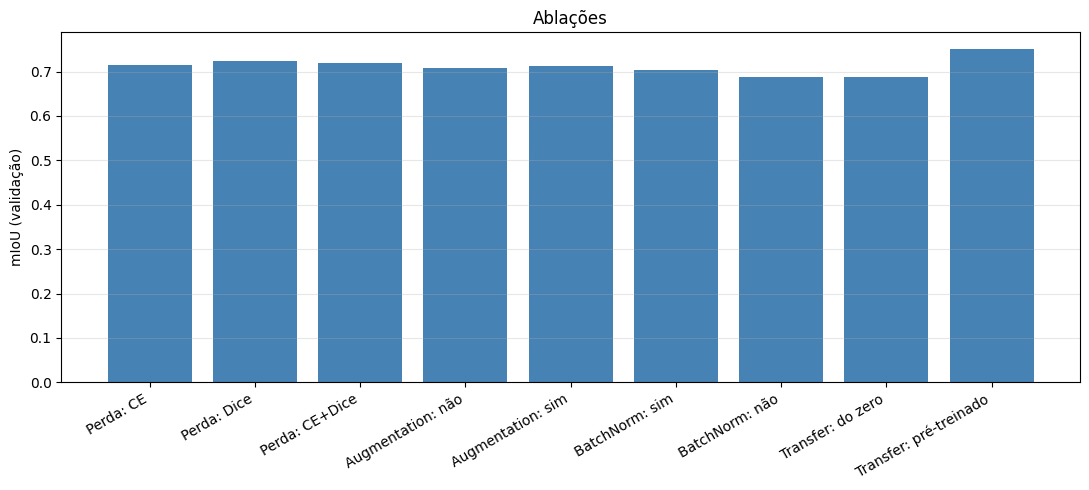

In [23]:
"""Resumo de todas as ablações."""
print(f"{'Experimento':<28}{'mIoU (val)':>12}")
print("-" * 40)
for tag, miou in ablation_results.items():
    print(f"{tag:<28}{miou:>12.4f}")

# Gráfico de barras das ablações
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(list(ablation_results.keys()), list(ablation_results.values()), color="steelblue")
ax.set_ylabel("mIoU (validação)"); ax.set_title("Ablações")
plt.xticks(rotation=30, ha="right"); plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("imagens/ablacoes.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Avaliação final no conjunto de teste

Carregamos os **melhores pesos** da melhor arquitetura (selecionada no comparativo) e avaliamos no
**conjunto de teste oficial** (nunca usado no treino/validação). Reportamos mIoU, Dice, pixel
accuracy e IoU **por classe**, geramos o `PETS_RESULTS.csv` (métricas por imagem) e uma grade de
predições visuais.

In [24]:
"""Avaliação final no teste com o melhor modelo."""
final_model = best_ctor().to(device)
final_model.load_state_dict(results[best_arch]["best_state"])
test_loss, test_metrics = evaluate(final_model, test_loader, nn.CrossEntropyLoss())

print(f"Melhor arquitetura: {best_arch}")
print(f"Teste  | mIoU {test_metrics['miou']:.4f} | Dice {test_metrics['dice']:.4f} | "
      f"pixAcc {test_metrics['pixel_acc']:.4f}")
print("\nIoU por classe:")
for cls, iou in zip(CLASS_NAMES, test_metrics["iou_per_class"]):
    print(f"  {cls:<8}: {iou:.4f}")

Melhor arquitetura: U-Net
Teste  | mIoU 0.7408 | Dice 0.8395 | pixAcc 0.9010

IoU por classe:
  animal  : 0.8158
  fundo   : 0.8995
  borda   : 0.5071


### Matriz de confusão (teste)

Matriz 3×3 normalizada por linha (classe verdadeira). A diagonal é a fração de pixels corretamente
classificados em cada classe.

In [ ]:
"""Matriz de confusão 3x3 (normalizada por classe verdadeira) no conjunto de teste."""
cm_metrics = SegmentationMetrics()
final_model.eval()
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = final_model(images).argmax(dim=1)
        cm_metrics.update(preds, masks)

cm = cm_metrics.confusion.float()
cm_norm = cm / (cm.sum(dim=1, keepdim=True) + 1e-7)   # normaliza por linha

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predição"); ax.set_ylabel("Classe verdadeira")
ax.set_title("Matriz de confusão (normalizada por linha)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("imagens/matriz_confusao.png", dpi=120, bbox_inches="tight")
plt.show()

In [25]:
"""Gera PETS_RESULTS.csv com as métricas (IoU/Dice/pixAcc) por imagem no teste."""
import csv

final_model.eval()
rows = []
with torch.no_grad():
    idx = 0
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = final_model(images).argmax(dim=1)
        for b in range(images.size(0)):
            m = SegmentationMetrics()
            m.update(preds[b:b + 1], masks[b:b + 1])
            s = m.summary()
            rows.append({"idx": idx, "miou": round(s["miou"], 4),
                         "dice": round(s["dice"], 4), "pixel_acc": round(s["pixel_acc"], 4)})
            idx += 1

with open("PETS_RESULTS.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["idx", "miou", "dice", "pixel_acc"])
    writer.writeheader()
    writer.writerows(rows)
print(f"PETS_RESULTS.csv salvo com {len(rows)} linhas.")

PETS_RESULTS.csv salvo com 3669 linhas.


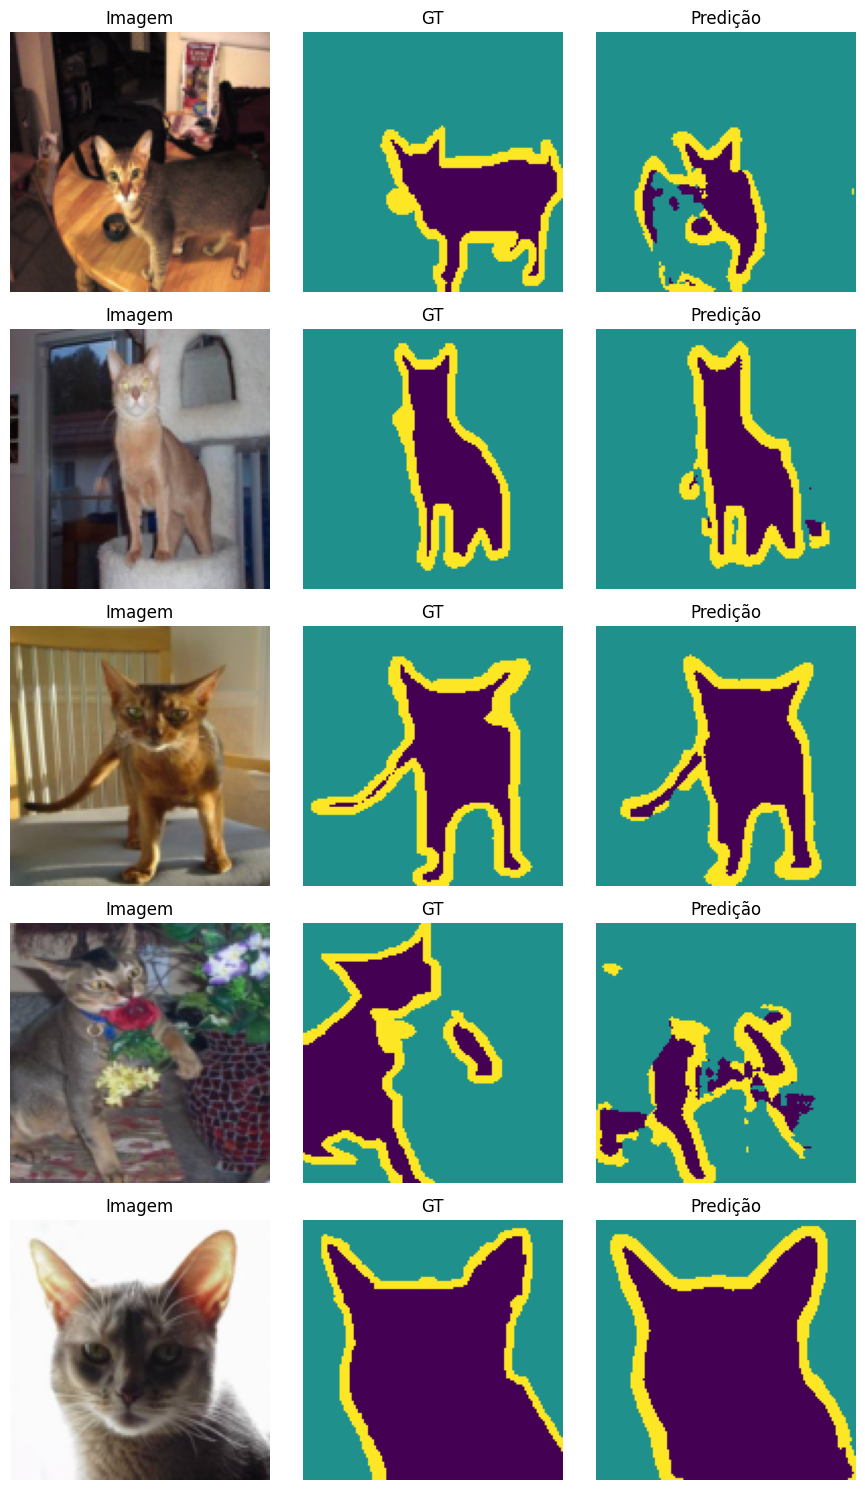

In [26]:
"""Grade de predições visuais: imagem | GT | predição."""
final_model.eval()
images, masks = next(iter(test_loader))
images_d = images.to(device)
with torch.no_grad():
    preds = final_model(images_d).argmax(dim=1).cpu()

n = min(5, images.size(0))
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
for i in range(n):
    axes[i, 0].imshow(denormalize(images[i]));                 axes[i, 0].set_title("Imagem")
    axes[i, 1].imshow(masks[i], cmap="viridis", vmin=0, vmax=2); axes[i, 1].set_title("GT")
    axes[i, 2].imshow(preds[i], cmap="viridis", vmin=0, vmax=2); axes[i, 2].set_title("Predição")
    for j in range(3):
        axes[i, j].axis("off")
plt.tight_layout()
plt.savefig("imagens/predicoes_teste.png", dpi=120, bbox_inches="tight")
plt.show()